In [1]:
import scanpy as sc
import anndata
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd

In [2]:
dir()

['In',
 'Out',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'anndata',
 'coo_matrix',
 'csr_matrix',
 'exit',
 'get_ipython',
 'io',
 'np',
 'os',
 'pd',
 'quit',
 'sc']

In [3]:
amp2 = sc.read("/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/AMPII_annotated.h5ad")
amp2

AnnData object with n_obs × n_vars = 322001 × 31897
    obs: 'library_id', 'ngenes', 'total_UMI', 'pct_mitochondrial', 'pct_ribosomal', 'scrub_doublet_scores', 'new_cluster_name_AMP2021', 'cell_type_AMP2021', 'cell_lineage', 'study_id', 'disease', 'cluster name'
    var: 'gene_ids', 'feature_types', 'highly_variable'
    uns: 'cluster name_colors'
    obsm: 'X_umap'
    layers: 'counts'

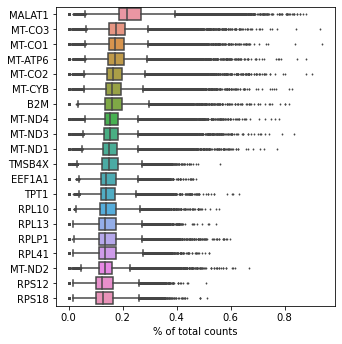

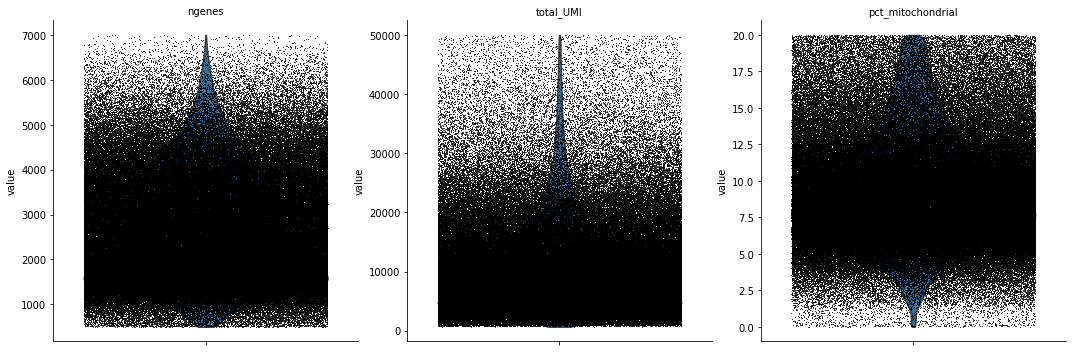

In [9]:
sc.pl.highest_expr_genes(amp2, n_top=20, )
sc.pl.violin(amp2, ['ngenes', 'total_UMI', 'pct_mitochondrial'],
             jitter=0.4, multi_panel=True)

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


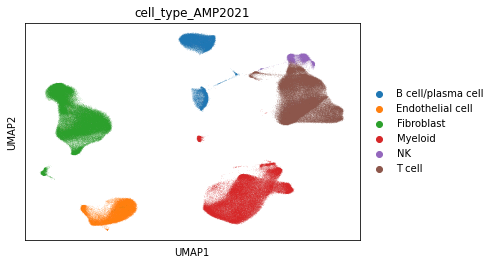

In [10]:
adata=amp2
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.pl.umap(adata, color=['cell_type_AMP2021'])

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


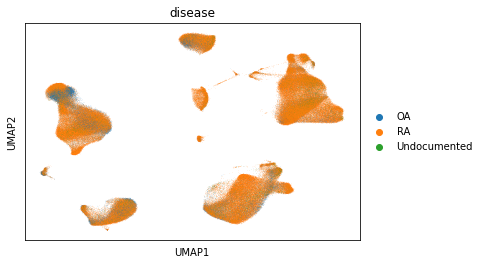

In [11]:
sc.pl.umap(adata, color=['disease'])

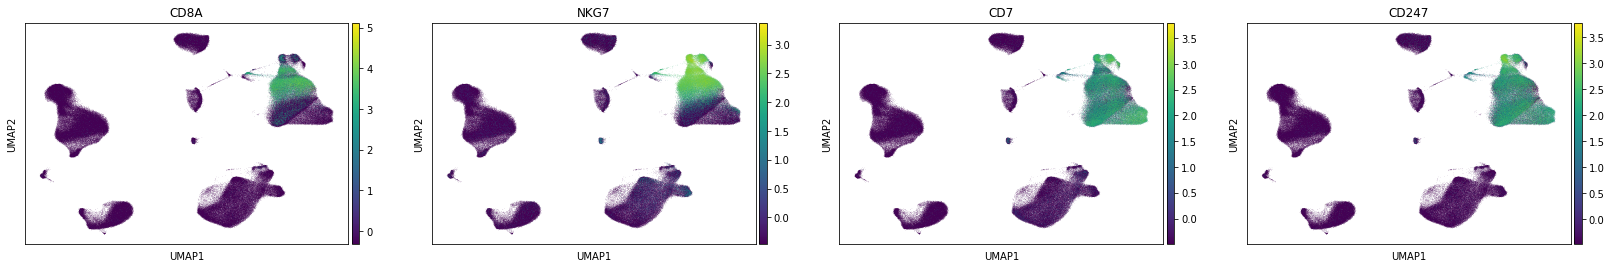

In [12]:
sc.pl.umap(adata, color=['CD8A', 'NKG7', 'CD7', 'CD247'])

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


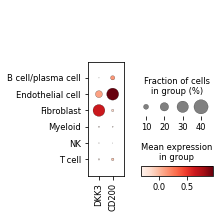

In [36]:
sc.pl.dotplot(adata, ['DKK3', 'CD200'], groupby='cell_type_AMP2021')


In [14]:
sc.tl.rank_genes_groups(adata, 'cell_type_AMP2021', method='t-test')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


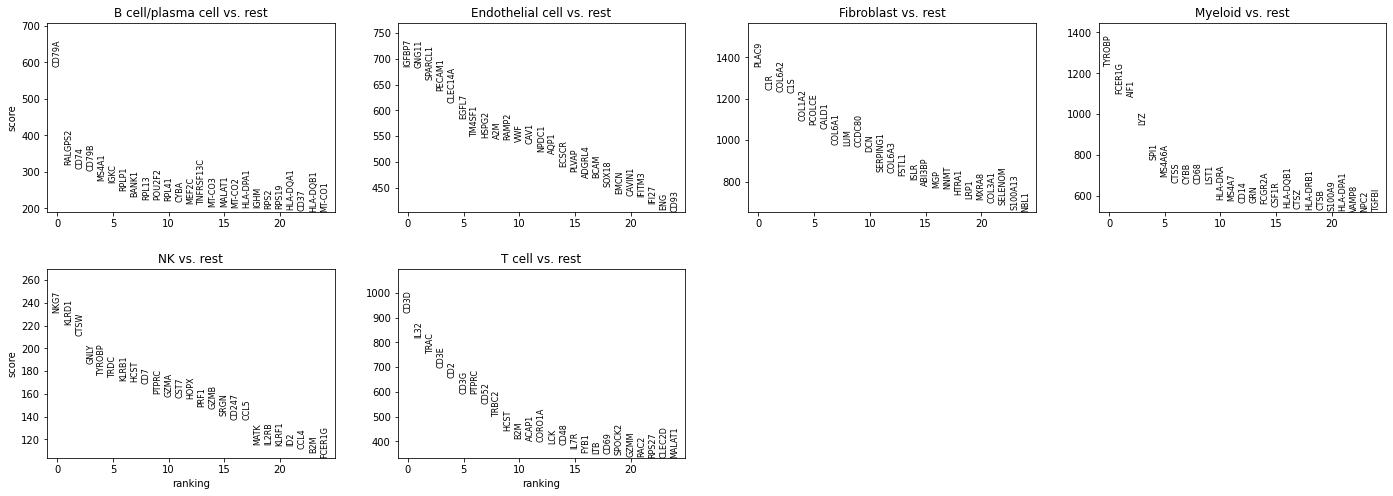

In [15]:
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [16]:
adata_fibro = adata[adata.obs['cell_type_AMP2021'].isin(['Fibroblast'])]
sc.pp.highly_variable_genes(adata_fibro, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro, max_value=10)
sc.tl.pca(adata_fibro, svd_solver='arpack')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)


In [30]:
sc.pp.neighbors(adata_fibro, n_neighbors=10, n_pcs=40)

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


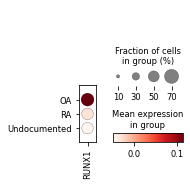

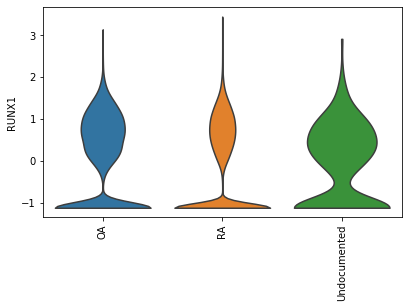

In [31]:
sc.pl.dotplot(adata_fibro, 'RUNX1', groupby='disease')
sc.pl.violin(adata_fibro, 'RUNX1', groupby='disease', rotation=90, size=0)

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


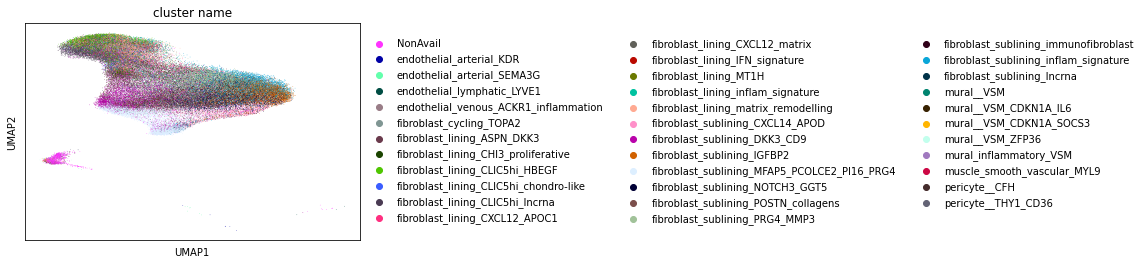

In [32]:

sc.pl.umap(adata_fibro, color=['cluster name'])

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


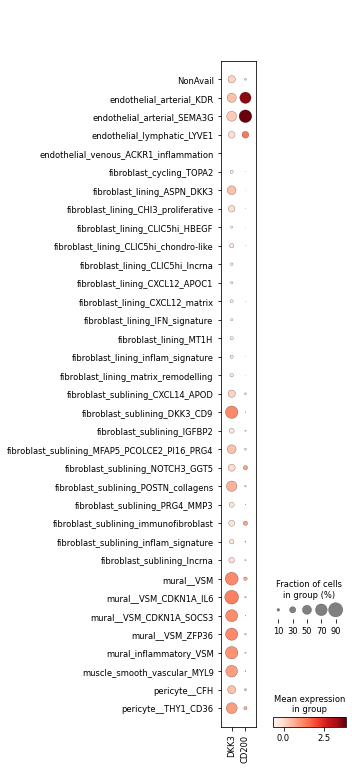

In [33]:
sc.pl.dotplot(adata_fibro, ['DKK3', 'CD200'], groupby='cluster name')


/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


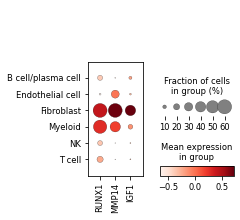

In [18]:
sc.pl.dotplot(adata, ['RUNX1', 'MMP14', 'IGF1'], groupby='cell_type_AMP2021')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


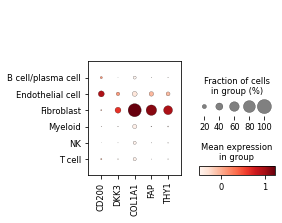

In [24]:
sc.pl.dotplot(adata, ['CD200','DKK3', 'COL1A1', 'FAP', 'THY1'], groupby='cell_type_AMP2021')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


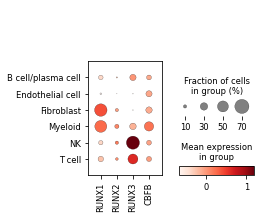

In [5]:
sc.pl.dotplot(adata, ['RUNX1', 'RUNX2', 'RUNX3', 'CBFB'], groupby='cell_type_AMP2021')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


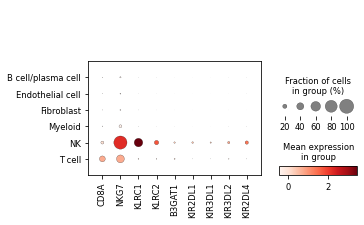

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


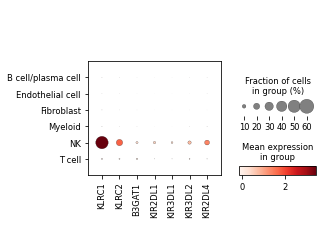

In [26]:
sc.pl.dotplot(adata, ['CD8A', 'NKG7','KLRC1', 'KLRC2', 'B3GAT1', 'KIR2DL1', 'KIR3DL1', 'KIR3DL2', 'KIR2DL4'], groupby='cell_type_AMP2021')
sc.pl.dotplot(adata, ['KLRC1', 'KLRC2', 'B3GAT1', 'KIR2DL1', 'KIR3DL1', 'KIR3DL2', 'KIR2DL4'], groupby='cell_type_AMP2021')

In [8]:
pip install dill

Defaulting to user installation because normal site-packages is not writeable
  Using cached dill-0.3.6-py3-none-any.whl (110 kB)
You should consider upgrading via the '/rds/bear-apps/2021a/EL8-ice/software/Python/3.9.5-GCCcore-10.3.0/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import dill
#dill.dump_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_env.db')
dill.load_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_env.db')

In [3]:
dir()

['In',
 'Out',
 '_',
 '_28',
 '_38',
 '_45',
 '_47',
 '_48',
 '_5',
 '_7',
 '_8',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 '_i47',
 '_i48',
 '_i49',
 '_i5',
 '_i50',
 '_i51',
 '_i52',
 '_i53',
 '_i54',
 '_i55',
 '_i56',
 '_i57',
 '_i58',
 '_i59',
 '_i6',
 '_i60',
 '_i61',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'adata',
 'adata_NKcells',
 'adata_fibro',
 'adata_fibro_SL_APOD',
 'adata_fibro_SL_CD9',
 'adata_fibro_SL_IGFBP2',
 'adata_fibro_SL_MFAP5_PCOLCE2_PI16_PRG4',
 'adata_fibro_SL_NOTCH3_GGT5',
 'adata_fibro_SL_POSTN

In [4]:
adata_NKcells = adata[adata.obs['cell_type_AMP2021'].isin(['NK'])]
sc.pp.highly_variable_genes(adata_NKcells, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_NKcells, max_value=10)
sc.tl.pca(adata_NKcells, svd_solver='arpack')
sc.pl.dotplot(adata_NKcells, ['KLRC1', 'KLRC2', 'B3GAT1', 'KIR2DL1', 'KIR3DL1', 'KIR3DL2', 'KIR2DL4'], groupby='disease')

NameError: name 'adata' is not defined

In [38]:
adata_NKcells

AnnData object with n_obs × n_vars = 8452 × 31897
    obs: 'library_id', 'ngenes', 'total_UMI', 'pct_mitochondrial', 'pct_ribosomal', 'scrub_doublet_scores', 'new_cluster_name_AMP2021', 'cell_type_AMP2021', 'cell_lineage', 'study_id', 'disease', 'cluster name'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cluster name_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'cell_type_AMP2021_colors', 'disease_colors', 'rank_genes_groups'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [7]:
results_file = '//rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/adata_NKcells.h5ad'  # the file that will store the analysis results
adata_NKcells.write(results_file)

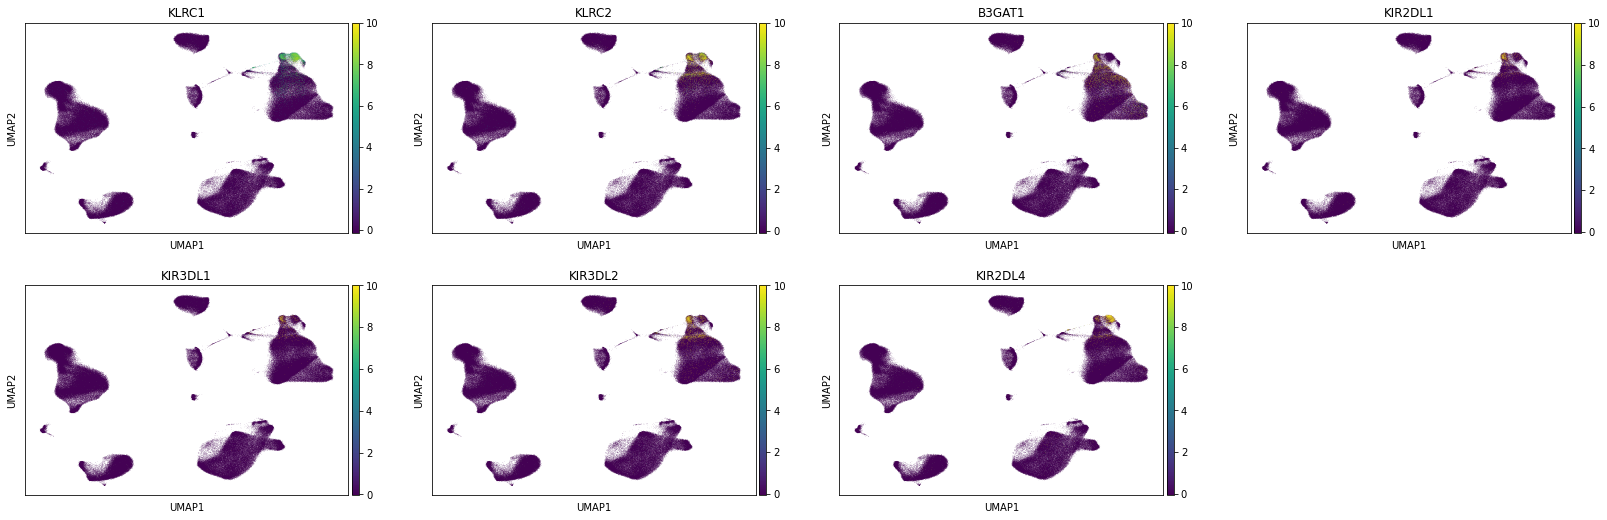

In [39]:
sc.pl.umap(adata, color=['KLRC1', 'KLRC2', 'B3GAT1', 'KIR2DL1', 'KIR3DL1', 'KIR3DL2', 'KIR2DL4'])

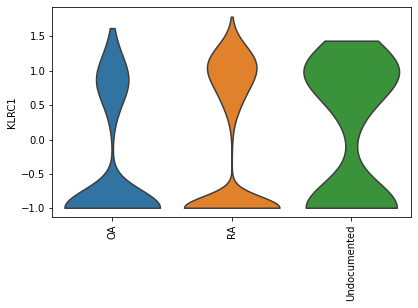

In [40]:
sc.pl.violin(adata_NKcells, 'KLRC1', groupby='disease', rotation=90, size=0)

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


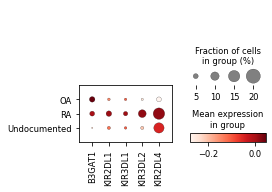

In [41]:
sc.pl.dotplot(adata_NKcells, ['B3GAT1', 'KIR2DL1', 'KIR3DL1', 'KIR3DL2', 'KIR2DL4'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:417: RuntimeWarning: invalid value encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:418: RuntimeWarning: invalid value encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:417: RuntimeWarning: invalid value encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:418: RuntimeWarning: invalid value encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/rds/homes/m/mahonyc/.loca

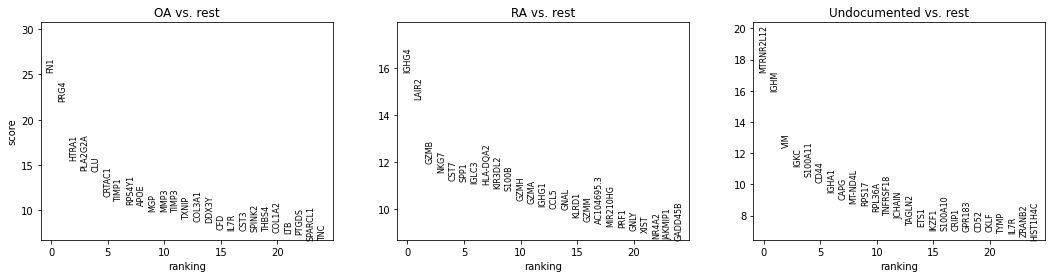

In [42]:
sc.tl.rank_genes_groups(adata_NKcells, 'disease', method='t-test')
sc.pl.rank_genes_groups(adata_NKcells, n_genes=25, sharey=False)

In [45]:
pd.DataFrame(adata_NKcells.uns['rank_genes_groups']['names']).head(50)

,OA,RA,Undocumented
0,FN1,IGHG4,MTRNR2L12
1,PRG4,LAIR2,IGHM
2,HTRA1,GZMB,VIM
3,PLA2G2A,NKG7,IGKC
4,CLU,CST7,S100A11
5,CRTAC1,SPP1,CD44
6,TIMP1,IGLC3,IGHA1
7,RPS4Y1,HLA-DQA2,CAPG
8,APOE,KIR3DL2,MT-ND4L
9,MGP,S100B,RPS17


/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


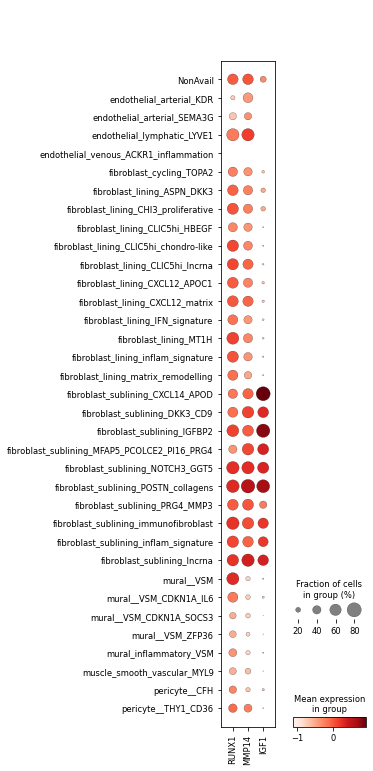

In [46]:
sc.pl.dotplot(adata_fibro, ['RUNX1', 'MMP14', 'IGF1'], groupby='cluster name')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


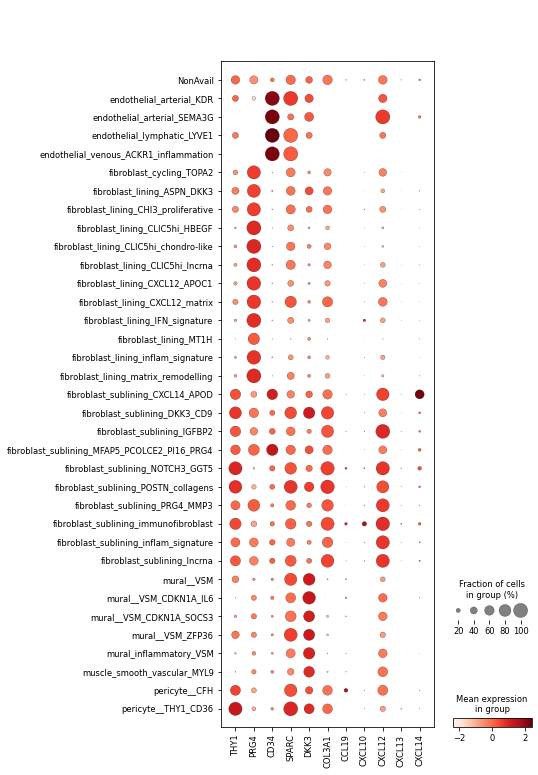

In [4]:
sc.pl.dotplot(adata_fibro, ['THY1', 'PRG4', 'CD34', 'SPARC', 'DKK3', 'COL3A1', 'CCL19', 'CXCL10', 'CXCL12', 'CXCL13', 'CXCL14'], groupby='cluster name')



/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


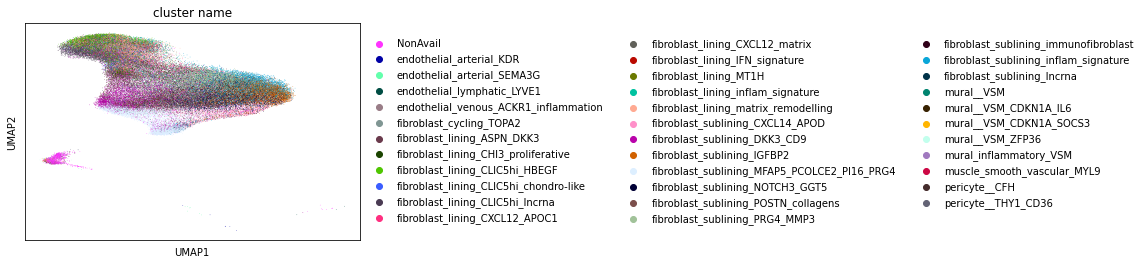

In [49]:
sc.pl.umap(adata_fibro, color=['cluster name'])

In [47]:
adata_fibro.obs['cell_type_AMP2021']

BRI-399_AAACCCAAGTCATTGC_AMP2021     Fibroblast
BRI-399_AAACCCAAGTGAATAC_AMP2021     Fibroblast
BRI-399_AAACCCACAGTCCGTG_AMP2021     Fibroblast
BRI-399_AAACCCAGTGAGTTTC_AMP2021     Fibroblast
BRI-399_AAACCCAGTGCTATTG_AMP2021     Fibroblast
                                        ...    
BRI-637R_TTCCTTCGTACATACC_AMP2021    Fibroblast
BRI-637R_TTCTTCCGTGTGTCGC_AMP2021    Fibroblast
BRI-637R_TTGCCTGGTCTGCCTT_AMP2021    Fibroblast
BRI-637R_TTGCTGCCATCGCTAA_AMP2021    Fibroblast
BRI-637R_TTTCACATCATGAGGG_AMP2021    Fibroblast
Name: cell_type_AMP2021, Length: 87065, dtype: category
Categories (1, object): ['Fibroblast']

In [48]:
adata_fibro

AnnData object with n_obs × n_vars = 87065 × 31897
    obs: 'library_id', 'ngenes', 'total_UMI', 'pct_mitochondrial', 'pct_ribosomal', 'scrub_doublet_scores', 'new_cluster_name_AMP2021', 'cell_type_AMP2021', 'cell_lineage', 'study_id', 'disease', 'cluster name'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cluster name_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'cell_type_AMP2021_colors', 'disease_colors', 'rank_genes_groups'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [46]:
results_file = '//rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_fibros_only.h5ad'  # the file that will store the analysis results
adata_fibro.write(results_file)


In [52]:
adata

AnnData object with n_obs × n_vars = 322001 × 31897
    obs: 'library_id', 'ngenes', 'total_UMI', 'pct_mitochondrial', 'pct_ribosomal', 'scrub_doublet_scores', 'new_cluster_name_AMP2021', 'cell_type_AMP2021', 'cell_lineage', 'study_id', 'disease', 'cluster name'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cluster name_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'cell_type_AMP2021_colors', 'disease_colors'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


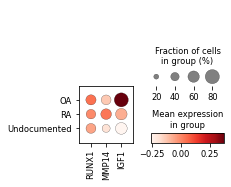

In [49]:
adata_fibro_SL_APOD = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_CXCL14_APOD'])]
sc.pp.highly_variable_genes(adata_fibro_SL_APOD, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_APOD, max_value=10)
sc.tl.pca(adata_fibro_SL_APOD, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_APOD, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')



/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


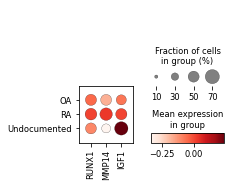

In [50]:
adata_fibro_SL_CD9 = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_DKK3_CD9'])]
sc.pp.highly_variable_genes(adata_fibro_SL_CD9, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_CD9, max_value=10)
sc.tl.pca(adata_fibro_SL_CD9, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_CD9, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


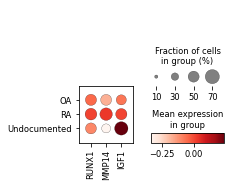

In [53]:
sc.pl.dotplot(adata_fibro_SL_CD9, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


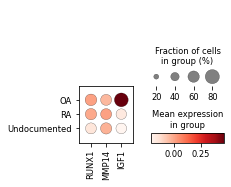

In [52]:
adata_fibro_SL_IGFBP2 = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_IGFBP2'])]
sc.pp.highly_variable_genes(adata_fibro_SL_IGFBP2, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_IGFBP2, max_value=10)
sc.tl.pca(adata_fibro_SL_IGFBP2, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_IGFBP2, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


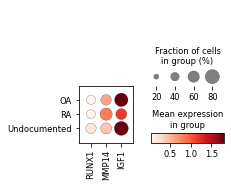

In [54]:
adata_fibro_SL_MFAP5_PCOLCE2_PI16_PRG4 = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_MFAP5_PCOLCE2_PI16_PRG4'])]
sc.pp.highly_variable_genes(adata_fibro_SL_MFAP5_PCOLCE2_PI16_PRG4, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_IGFBP2, max_value=10)
sc.tl.pca(adata_fibro_SL_MFAP5_PCOLCE2_PI16_PRG4, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_MFAP5_PCOLCE2_PI16_PRG4, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


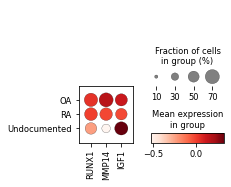

In [55]:
adata_fibro_SL_NOTCH3_GGT5 = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_NOTCH3_GGT5'])]
sc.pp.highly_variable_genes(adata_fibro_SL_NOTCH3_GGT5, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_NOTCH3_GGT5, max_value=10)
sc.tl.pca(adata_fibro_SL_NOTCH3_GGT5, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_NOTCH3_GGT5, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


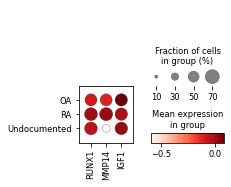

In [56]:
adata_fibro_SL_POSTN_collagens = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_POSTN_collagens'])]
sc.pp.highly_variable_genes(adata_fibro_SL_POSTN_collagens, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_POSTN_collagens, max_value=10)
sc.tl.pca(adata_fibro_SL_POSTN_collagens, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_POSTN_collagens, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


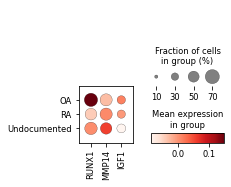

In [57]:
adata_fibro_SL_PRG4_MMP3 = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_PRG4_MMP3'])]
sc.pp.highly_variable_genes(adata_fibro_SL_PRG4_MMP3, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_PRG4_MMP3, max_value=10)
sc.tl.pca(adata_fibro_SL_PRG4_MMP3, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_PRG4_MMP3, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


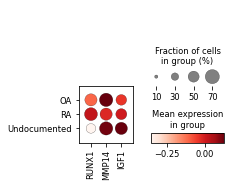

In [58]:
adata_fibro_SL_immunoflibroblast = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_immunofibroblast'])]
sc.pp.highly_variable_genes(adata_fibro_SL_immunoflibroblast, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_immunoflibroblast, max_value=10)
sc.tl.pca(adata_fibro_SL_immunoflibroblast, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_immunoflibroblast, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


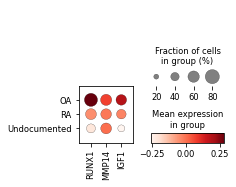

In [59]:
adata_fibro_SL_inflam_signature = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_inflam_signature'])]
sc.pp.highly_variable_genes(adata_fibro_SL_inflam_signature, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_inflam_signature, max_value=10)
sc.tl.pca(adata_fibro_SL_inflam_signature, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_inflam_signature, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


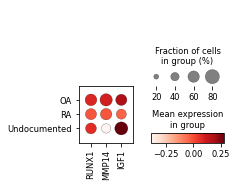

In [60]:
adata_fibro_SL_lncrna = adata[adata.obs['cluster name'].isin(['fibroblast_sublining_lncrna'])]
sc.pp.highly_variable_genes(adata_fibro_SL_lncrna, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro_SL_lncrna, max_value=10)
sc.tl.pca(adata_fibro_SL_lncrna, svd_solver='arpack')
sc.pl.dotplot(adata_fibro_SL_lncrna, ['RUNX1', 'MMP14', 'IGF1'], groupby='disease')

In [2]:
import dill
#dill.dump_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_env_safe.db')
dill.load_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_env.db')

AttributeError: Can't get attribute '_unpickle_block' on <module 'pandas._libs.internals' from '/rds/bear-apps/2021b/EL8-cas/software/SciPy-bundle/2021.10-foss-2021b/lib/python3.9/site-packages/pandas/_libs/internals.cpython-39-x86_64-linux-gnu.so'>

In [62]:
dir()

['In',
 'Out',
 '_',
 '_28',
 '_38',
 '_45',
 '_47',
 '_48',
 '_5',
 '_7',
 '_8',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 '_i47',
 '_i48',
 '_i49',
 '_i5',
 '_i50',
 '_i51',
 '_i52',
 '_i53',
 '_i54',
 '_i55',
 '_i56',
 '_i57',
 '_i58',
 '_i59',
 '_i6',
 '_i60',
 '_i61',
 '_i62',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'adata',
 'adata_NKcells',
 'adata_fibro',
 'adata_fibro_SL_APOD',
 'adata_fibro_SL_CD9',
 'adata_fibro_SL_IGFBP2',
 'adata_fibro_SL_MFAP5_PCOLCE2_PI16_PRG4',
 'adata_fibro_SL_NOTCH3_GGT5',
 'adata_fibro

In [63]:
import csv
import numpy as np
import pandas as pd





In [64]:
variblegenes=amp2.var['highly_variable']
variblegenes_df = pd.DataFrame(variblegenes) 
variblegenes_df.to_csv('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_variblegenes.csv') 

In [10]:
amp2

AnnData object with n_obs × n_vars = 322001 × 31897
    obs: 'library_id', 'ngenes', 'total_UMI', 'pct_mitochondrial', 'pct_ribosomal', 'scrub_doublet_scores', 'new_cluster_name_AMP2021', 'cell_type_AMP2021', 'cell_lineage', 'study_id', 'disease', 'cluster name'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cluster name_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'cell_type_AMP2021_colors', 'disease_colors', 'rank_genes_groups'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [11]:
counts_firbos=adata_fibro.layers
#counts_firbos_df = pd.DataFrame(counts_firbos) 
#counts_firbos_df.to_csv('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/counts_firbos.csv') 

In [12]:
counts_firbos

Layers with keys: counts

In [8]:
PCs=amp2.varm['PCs']
Pcs_df=pd.DataFrame(PCs)
PCs

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.00984763,  0.03876472,  0.07562955, ...,  0.00748493,
         0.02424962, -0.00221397],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [66]:
adata_Tcells = adata[adata.obs['cell_type_AMP2021'].isin(['Tcells'])]
#results_file = '//rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/adata_Tcells.h5ad'  # the file that will store the analysis results
#adata_Tcells.write(results_file)

In [67]:
adata_Bcells = adata[adata.obs['cell_type_AMP2021'].isin(['B cell/plasma cell'])]
#results_file = '//rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/adata_Bcells.h5ad'  # the file that will store the analysis results
#adata_Bcells.write(results_file)

In [68]:
adata.obs['cell_type_AMP2021']

BRI-399_AAACCCAAGTCATTGC_AMP2021           Fibroblast
BRI-399_AAACCCAAGTGAATAC_AMP2021           Fibroblast
BRI-399_AAACCCACAGTCCGTG_AMP2021           Fibroblast
BRI-399_AAACCCAGTAGGAGGG_AMP2021              Myeloid
BRI-399_AAACCCAGTGAGTTTC_AMP2021           Fibroblast
                                           ...       
BRI-637R_TTTATGCGTCTACTGA_AMP2021    Endothelial cell
BRI-637R_TTTATGCGTGCCTATA_AMP2021             Myeloid
BRI-637R_TTTCACATCATGAGGG_AMP2021          Fibroblast
BRI-637R_TTTGATCGTTGGAGAC_AMP2021    Endothelial cell
BRI-637R_TTTGTTGTCTAGTGAC_AMP2021              T cell
Name: cell_type_AMP2021, Length: 322001, dtype: category
Categories (6, object): ['B cell/plasma cell', 'Endothelial cell', 'Fibroblast', 'Myeloid', 'NK', 'T cell']

In [ ]:
import dill
dill.dump_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_env_safe.db')

In [14]:
adata_fibro.T.write_csvs('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_counts.csv')

In [15]:
amp2

AnnData object with n_obs × n_vars = 322001 × 31897
    obs: 'library_id', 'ngenes', 'total_UMI', 'pct_mitochondrial', 'pct_ribosomal', 'scrub_doublet_scores', 'new_cluster_name_AMP2021', 'cell_type_AMP2021', 'cell_lineage', 'study_id', 'disease', 'cluster name'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cluster name_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'cell_type_AMP2021_colors', 'disease_colors', 'rank_genes_groups'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [18]:
adata_fibro_raw=adata_fibro.raw.to_adata()

AttributeError: 'NoneType' object has no attribute 'to_adata'

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


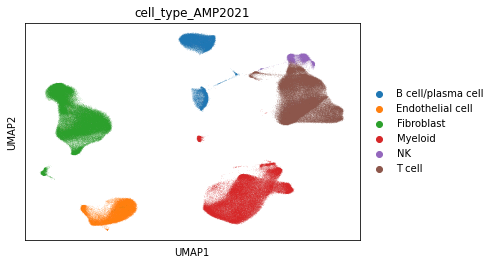

In [6]:
sc.pl.umap(adata, color=['cell_type_AMP2021'])

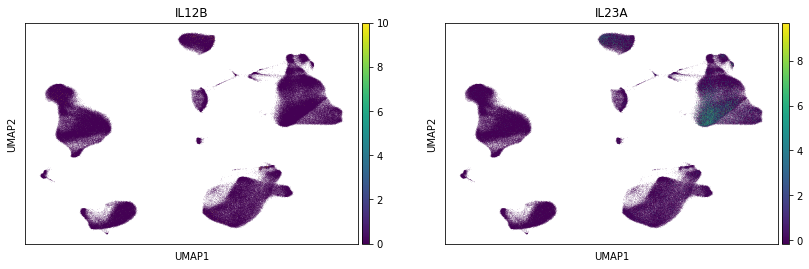

In [5]:
sc.pl.umap(adata, color=['IL12B', 'IL23A'])

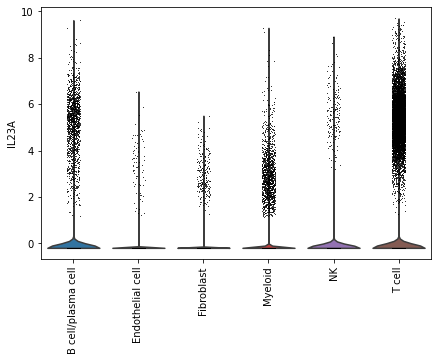

In [2]:
sc.pl.violin(adata, 'IL23A', groupby='cell_type_AMP2021', rotation=90, size=1)

In [1]:
import scanpy as sc